# Phase 4 - Evaluation of the best model (CICIDS2017)

We evaluate the best model from the bake-off on the full test set, compare it
to the static rule baseline, and explain its predictions.

In [1]:
# imports
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import joblib

sns.set(style="whitegrid")
BASE = "/home/samouraifox/Work/stuff/S6/Notes_Ai/projet-final/model-building/Detection-explicable-danomalies"

In [2]:
# load the test set and the saved artifacts
df = pd.read_parquet(BASE + "/data/processed/test_set.parquet")
features = joblib.load(BASE + "/models/features.pkl")
scaler = joblib.load(BASE + "/models/scaler.pkl")
best_model = joblib.load(BASE + "/models/best_model.pkl")
benign_means = joblib.load(BASE + "/models/benign_means.pkl")
with open(BASE + "/models/best_model_meta.json") as f:
    best_model_meta = json.load(f)
with open(BASE + "/models/cv_results.json") as f:
    cv_results = json.load(f)
with open(BASE + "/models/rule_baseline.json") as f:
    rule_baseline = json.load(f)

best_name = best_model_meta["name"]
print("Best model:", best_name)
print("Test set:", df.shape)

Best model: XGBoost
Test set: (756240, 73)


## Predictions on the test set

The best model expects scaled features, so we scale with the saved scaler
before predicting. The rule baseline uses the raw features.

In [3]:
# features, scaled features and ground truth
X = df[features]
Xs = scaler.transform(X)
y_true = df["Label_binary"]

# best model: prediction + risk score (probability of attack)
y_pred_best = best_model.predict(Xs)
proba_best = best_model.predict_proba(Xs)[:, 1]

# rule baseline on raw features (logical OR of the 5 rules)
th_avg_packet_size = 496.0
th_bwd_packets_s = 58823.0
th_flow_packets_s = 500000.0
th_fwd_packets_short = 3
th_flow_duration_long = 1000000.0
th_flow_bytes_s = 12000000.0
r1 = X["Average Packet Size"] > th_avg_packet_size
r2 = X["Bwd Packets/s"] > th_bwd_packets_s
r3 = X["Flow Packets/s"] > th_flow_packets_s
r4 = (X["Total Fwd Packets"] <= th_fwd_packets_short) & (X["Flow Duration"] > th_flow_duration_long)
r5 = X["Flow Bytes/s"] > th_flow_bytes_s
y_pred_rule = (r1 | r2 | r3 | r4 | r5).astype(int)

print("Attacks predicted - best model:", int(y_pred_best.sum()))
print("Attacks predicted - rules     :", int(y_pred_rule.sum()))

Attacks predicted - best model: 127997
Attacks predicted - rules     : 176103


## Bake-off ranking (cross-validation F1)

Bar chart of the cross-validation F1 of the 7 models, read from cv_results.json.
The best model is highlighted in green.

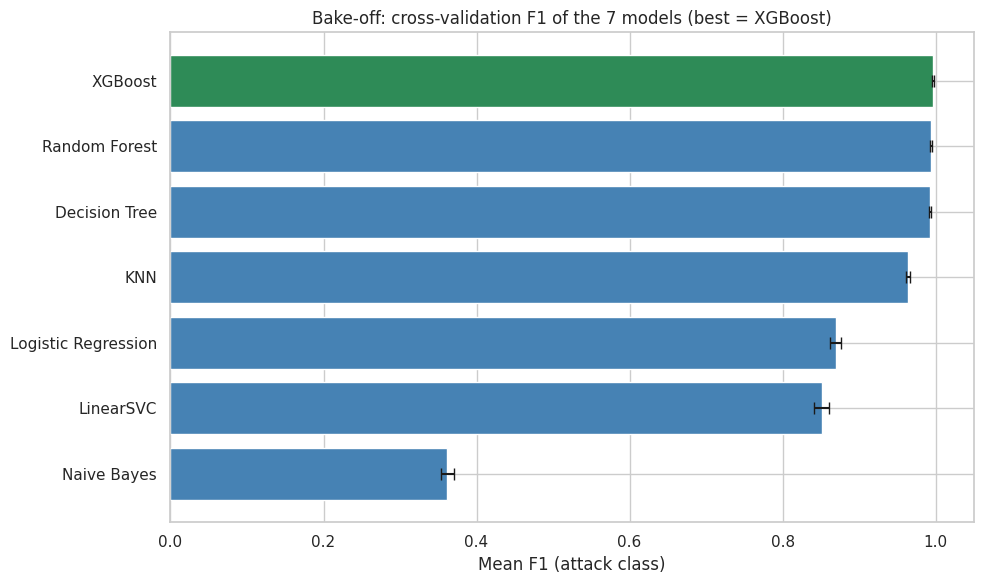

In [4]:
# bar chart of the cross-validation F1 of the 7 models
names = list(cv_results.keys())
f1_means = [cv_results[n]["cv_f1_mean"] for n in names]
f1_stds = [cv_results[n]["cv_f1_std"] for n in names]
colors = ["seagreen" if cv_results[n]["selected"] else "steelblue" for n in names]

# sort by ascending F1 for readability
order = np.argsort(f1_means)
names = [names[i] for i in order]
f1_means = [f1_means[i] for i in order]
f1_stds = [f1_stds[i] for i in order]
colors = [colors[i] for i in order]

plt.figure(figsize=(10, 6))
plt.barh(names, f1_means, xerr=f1_stds, color=colors, capsize=4)
plt.title("Bake-off: cross-validation F1 of the 7 models (best = " + best_name + ")")
plt.xlabel("Mean F1 (attack class)")
plt.xlim(0, 1.05)
plt.tight_layout()
plt.savefig(BASE + "/reports/figures/11_bakeoff_cv_f1.png", dpi=120)
plt.show()

## Confusion matrices: best model vs rules

False positives (BENIGN flagged as attack) are the top-right cell: these are
the useless alerts the SOC analysts have to handle.

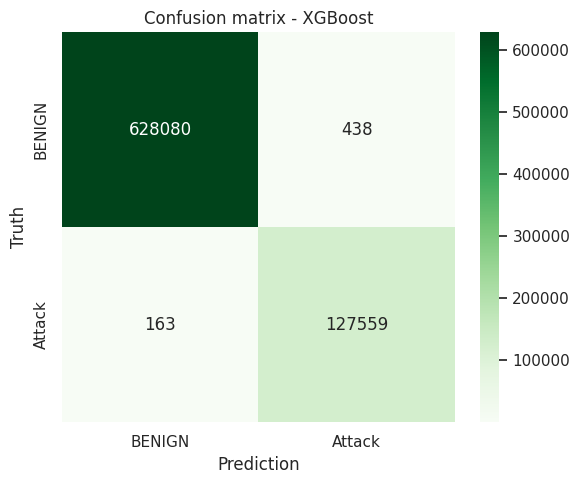

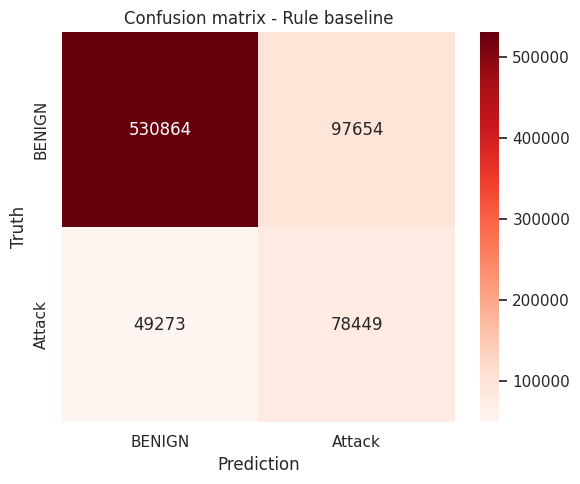

In [5]:
cm_best = confusion_matrix(y_true, y_pred_best)
cm_rule = confusion_matrix(y_true, y_pred_rule)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_best, annot=True, fmt="d", cmap="Greens",
            xticklabels=["BENIGN", "Attack"], yticklabels=["BENIGN", "Attack"])
plt.title("Confusion matrix - " + best_name)
plt.xlabel("Prediction")
plt.ylabel("Truth")
plt.tight_layout()
plt.savefig(BASE + "/reports/figures/08_cm_best_model.png", dpi=120)
plt.show()

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rule, annot=True, fmt="d", cmap="Reds",
            xticklabels=["BENIGN", "Attack"], yticklabels=["BENIGN", "Attack"])
plt.title("Confusion matrix - Rule baseline")
plt.xlabel("Prediction")
plt.ylabel("Truth")
plt.tight_layout()
plt.savefig(BASE + "/reports/figures/06_cm_regles.png", dpi=120)
plt.show()

## Comparison table and false positive reduction

In [6]:
# false positives and true negatives (cell [0, 1] and [0, 0])
fp_best = int(cm_best[0, 1])
tn_best = int(cm_best[0, 0])
fp_rule = int(cm_rule[0, 1])
tn_rule = int(cm_rule[0, 0])
fp_rate_best = fp_best / (fp_best + tn_best)
fp_rate_rule = fp_rule / (fp_rule + tn_rule)

comparison = {"Model": [], "Precision": [], "Recall": [], "F1": [],
              "Accuracy": [], "False positives": [], "FP rate": []}
rows = [("Rules", y_pred_rule, fp_rule, fp_rate_rule),
        (best_name, y_pred_best, fp_best, fp_rate_best)]
for name, y_pred, fp, fpr in rows:
    comparison["Model"].append(name)
    comparison["Precision"].append(precision_score(y_true, y_pred, zero_division=0))
    comparison["Recall"].append(recall_score(y_true, y_pred, zero_division=0))
    comparison["F1"].append(f1_score(y_true, y_pred, zero_division=0))
    comparison["Accuracy"].append(accuracy_score(y_true, y_pred))
    comparison["False positives"].append(fp)
    comparison["FP rate"].append(fpr)

df_comparison = pd.DataFrame(comparison)
print("=== Comparison on the test set ===")
print(df_comparison.round(4).to_string(index=False))

fp_reduction = (fp_rule - fp_best) / fp_rule * 100
print(f"\nFalse positive reduction ({best_name} vs Rules): {fp_reduction:.2f} %")

=== Comparison on the test set ===
  Model  Precision  Recall     F1  Accuracy  False positives  FP rate
  Rules     0.4455  0.6142 0.5164    0.8057            97654   0.1554
XGBoost     0.9966  0.9987 0.9976    0.9992              438   0.0007

False positive reduction (XGBoost vs Rules): 99.55 %


## Feature importance (best model)

Trees and gradient boosting expose feature_importances_; linear models expose
coef_. We show the 20 most important features.

Importance method: feature_importances_
Bwd Packet Length Std          0.4529
Average Packet Size            0.1975
Bwd Header Length              0.1022
Max Packet Length              0.0570
Idle Mean                      0.0436
Flow Bytes/s                   0.0202
Active Std                     0.0184
FIN Flag Count                 0.0149
Fwd Packet Length Std          0.0130
Fwd Header Length              0.0067
Total Length of Bwd Packets    0.0049
Fwd IAT Mean                   0.0048
Fwd PSH Flags                  0.0047
Bwd Packet Length Mean         0.0045
Destination Port               0.0043
min_seg_size_forward           0.0042
Bwd IAT Mean                   0.0040
Total Backward Packets         0.0039
Idle Max                       0.0032
Fwd IAT Min                    0.0031


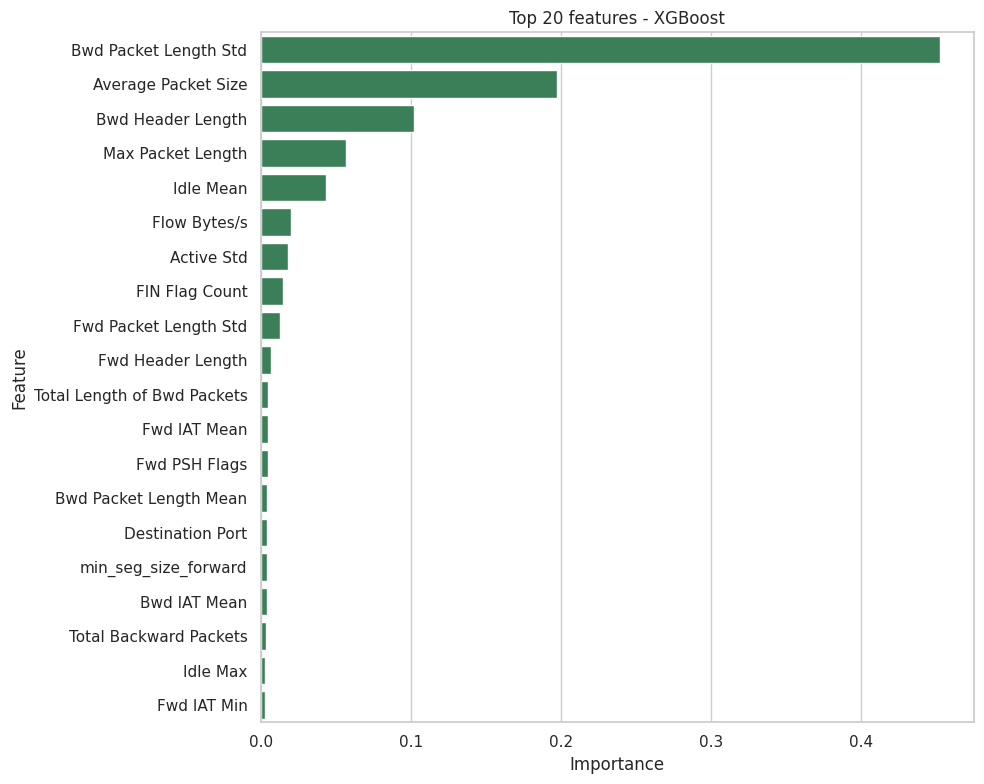

In [7]:
if hasattr(best_model, "feature_importances_"):
    method = "feature_importances_"
    importances = pd.Series(best_model.feature_importances_, index=features).sort_values(ascending=False)
elif hasattr(best_model, "coef_"):
    method = "|coef_|"
    importances = pd.Series(np.abs(np.ravel(best_model.coef_)), index=features).sort_values(ascending=False)
else:
    method = "uniform (no importance available)"
    importances = pd.Series(np.ones(len(features)), index=features)

print("Importance method:", method)
top20 = importances.head(20)
print(top20.round(4).to_string())

plt.figure(figsize=(10, 8))
sns.barplot(x=top20.values, y=top20.index, color="seagreen")
plt.title("Top 20 features - " + best_name)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(BASE + "/reports/figures/09_importance_features.png", dpi=120)
plt.show()

## Why this alert (per-flow explanation)

For one well-detected attack per family, we show how far each feature is from
normal traffic, measured in standard deviations from the BENIGN mean (z-score).
This puts every feature on the same scale. Bars beyond +/- 3 std are abnormal
(red) and point both ways: a feature can be abnormally high or abnormally low.
These abnormal features are the reasons for the alert.

DoS: top abnormal features -> ['Bwd Packet Length Std', 'Fwd IAT Std', 'Packet Length Variance']
DDoS: top abnormal features -> ['Bwd Packet Length Std', 'Bwd Packet Length Mean', 'Avg Bwd Segment Size']
PortScan: top abnormal features -> ['Bwd Packet Length Std', 'Bwd Packet Length Max', 'Avg Bwd Segment Size']


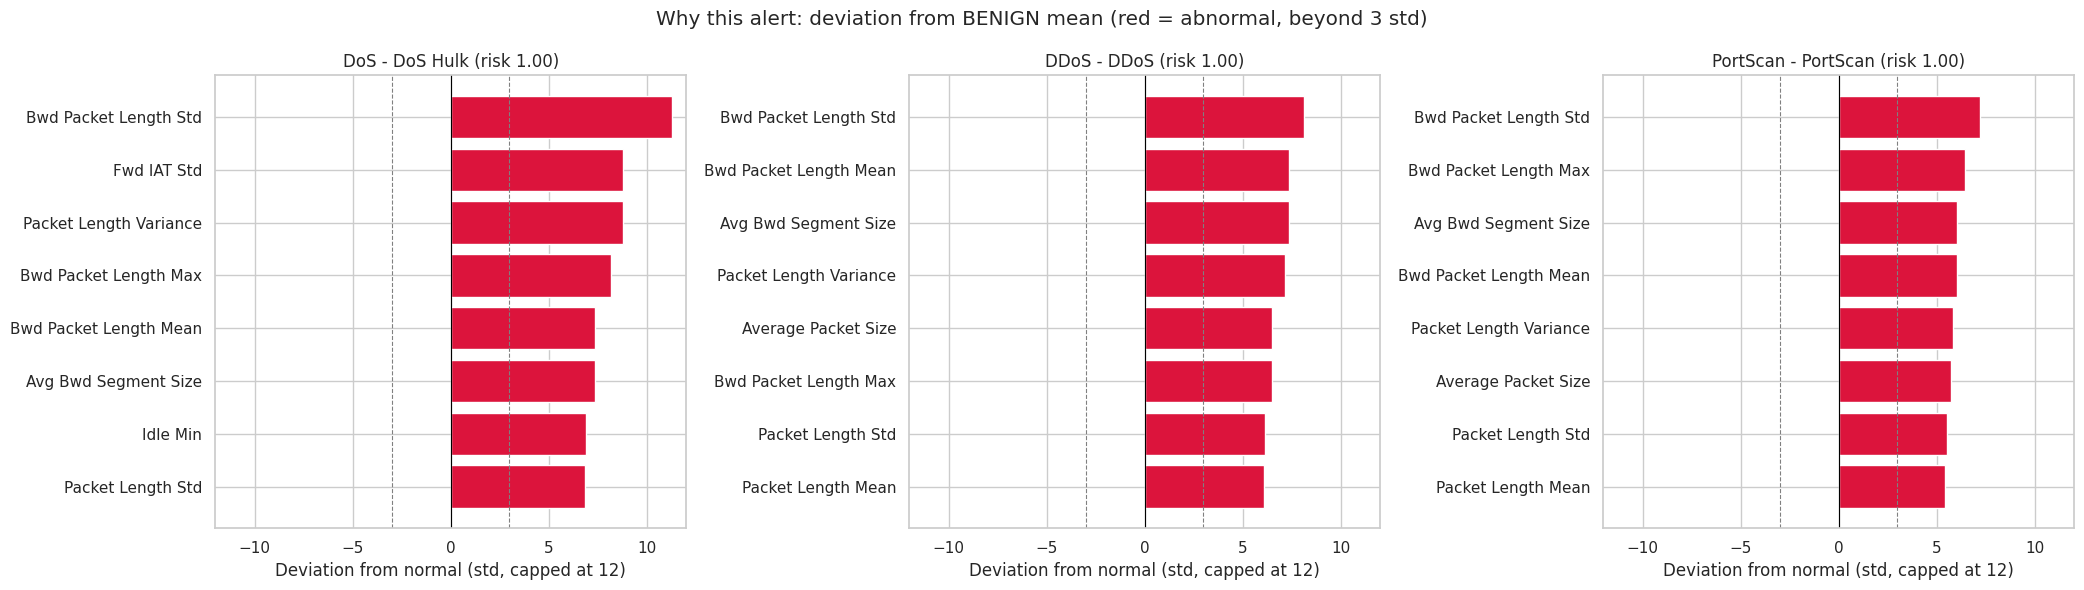

In [8]:
df_eval = df.copy()
df_eval["pred"] = y_pred_best
df_eval["proba"] = proba_best

# benign mean and std per feature (from the BENIGN flows of the test set)
benign_mask = df["Label_binary"] == 0
benign_mean = df.loc[benign_mask, features].mean()
benign_std = df.loc[benign_mask, features].std().replace(0, np.nan)

# one well-detected attack per family (highest risk score)
target_families = ["DoS", "DDoS", "PortScan"]
alert_idx = []
for fam in target_families:
    mask = (df_eval["Label_group"] == fam) & (df_eval["Label_binary"] == 1) & (df_eval["pred"] == 1)
    cand = df_eval[mask]
    if len(cand) > 0:
        alert_idx.append(cand["proba"].idxmax())

threshold = 3.0   # abnormal if more than 3 std from the benign mean
cap = 12.0        # cap the displayed deviation so the chart stays readable

fig, axs = plt.subplots(1, len(alert_idx), figsize=(7 * len(alert_idx), 6))
if len(alert_idx) == 1:
    axs = [axs]
for i, idx in enumerate(alert_idx):
    row = df_eval.loc[idx]
    # deviation of the flow from normal traffic, in standard deviations
    z = (X.loc[idx, features].astype(float) - benign_mean) / benign_std
    z = z.dropna()
    z_top = z.reindex(z.abs().sort_values(ascending=False).index).head(8)
    print(f"{row['Label_group']}: top abnormal features ->", list(z_top.index[:3]))

    z_plot = z_top.iloc[::-1]                 # most abnormal on top
    z_draw = z_plot.clip(-cap, cap)           # cap long bars for readability
    bar_colors = ["crimson" if abs(v) > threshold else "steelblue" for v in z_plot.values]
    y_pos = np.arange(len(z_plot))
    axs[i].barh(y_pos, z_draw.values, color=bar_colors)
    axs[i].axvline(0, color="black", linewidth=0.8)
    axs[i].axvline(threshold, color="gray", linestyle="--", linewidth=0.8)
    axs[i].axvline(-threshold, color="gray", linestyle="--", linewidth=0.8)
    axs[i].set_xlim(-cap, cap)
    axs[i].set_yticks(y_pos)
    axs[i].set_yticklabels(z_plot.index)
    axs[i].set_xlabel("Deviation from normal (std, capped at 12)")
    axs[i].set_title(f"{row['Label_group']} - {row['Label']} (risk {row['proba']:.2f})")
plt.suptitle("Why this alert: deviation from BENIGN mean (red = abnormal, beyond 3 std)")
plt.tight_layout()
plt.savefig(BASE + "/reports/figures/10_explication_alerte.png", dpi=120)
plt.show()

## Save the metrics

In [9]:
metrics = {"best_model": best_name,
           "fp_reduction_vs_rules": round(float(fp_reduction), 2),
           "test": {},
           "bakeoff": cv_results}
for name, y_pred, fp, fpr in rows:
    metrics["test"][name] = {
        "precision": round(float(precision_score(y_true, y_pred, zero_division=0)), 4),
        "recall": round(float(recall_score(y_true, y_pred, zero_division=0)), 4),
        "f1": round(float(f1_score(y_true, y_pred, zero_division=0)), 4),
        "accuracy": round(float(accuracy_score(y_true, y_pred)), 4),
        "fp": fp,
        "fp_rate": round(float(fpr), 4),
    }
with open(BASE + "/reports/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)
print("Metrics saved -> reports/metrics.json")
print(json.dumps(metrics, indent=2, ensure_ascii=False))

Metrics saved -> reports/metrics.json
{
  "best_model": "XGBoost",
  "fp_reduction_vs_rules": 99.55,
  "test": {
    "Rules": {
      "precision": 0.4455,
      "recall": 0.6142,
      "f1": 0.5164,
      "accuracy": 0.8057,
      "fp": 97654,
      "fp_rate": 0.1554
    },
    "XGBoost": {
      "precision": 0.9966,
      "recall": 0.9987,
      "f1": 0.9976,
      "accuracy": 0.9992,
      "fp": 438,
      "fp_rate": 0.0007
    }
  },
  "bakeoff": {
    "LinearSVC": {
      "cv_f1_mean": 0.8509,
      "cv_f1_std": 0.0094,
      "accuracy": 0.9513,
      "precision": 0.8712,
      "recall": 0.8351,
      "f1": 0.8528,
      "selected": false
    },
    "Decision Tree": {
      "cv_f1_mean": 0.9928,
      "cv_f1_std": 0.0014,
      "accuracy": 0.9982,
      "precision": 0.9927,
      "recall": 0.9967,
      "f1": 0.9947,
      "selected": false
    },
    "Logistic Regression": {
      "cv_f1_mean": 0.8694,
      "cv_f1_std": 0.0074,
      "accuracy": 0.9572,
      "precision": 0.8817,